Cargando e0103...
Generating record list for: e0103
Generating list of all files for: e0103
Finished downloading files


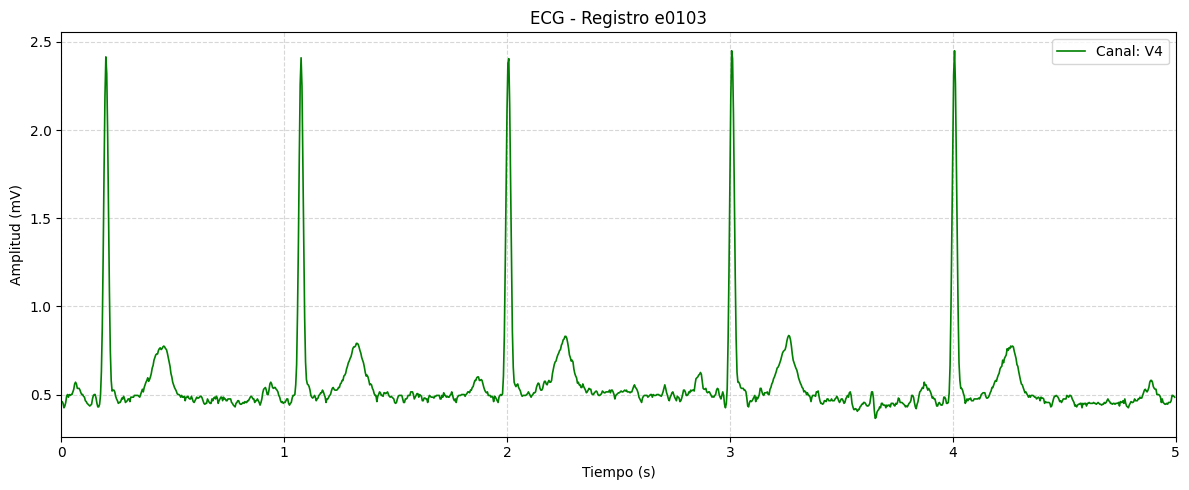

Se han graficado 1250 muestras a una fs de 250 Hz.


In [ ]:

#European ST-T Database - https://physionet.org/content/edb/1.0.0/
#Para visualizar la señal e0103.atr - https://physionet.org/lightwave/

!pip install pandas==2.2.2 wfdb -q
import wfdb
import matplotlib.pyplot as plt
import numpy as np

# Configuracion para obtener la señal
registro = 'e0103'
db = 'edb'
segundos_a_graficar = 5

try:
    print(f"Cargando {registro}...")
    #A partir del registro y el db descargamos los archivos
    wfdb.dl_database(db, dl_dir='.', records=[registro], annotators=['atr'])

    record = wfdb.rdrecord(registro)
    signal = record.p_signal
    fs = record.fs

    # Se calcula el limite de muestras para 5 segundos
    limite_muestras = int(segundos_a_graficar * fs)

    #Parametros para la visualizacion
    N = signal.shape[0]
    t = np.arange(N) / fs

    plt.figure(figsize=(12, 5))

    #Se grafica el canal 0 , es decir para V4
    canal = 0
    plt.plot(t[:limite_muestras], signal[:limite_muestras, canal],
             color='green', linewidth=1.2, label=f'Canal: {record.sig_name[canal]}')

    plt.title(f"ECG - Registro {registro}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud (mV)")
    plt.legend(loc='upper right')
    plt.grid(True, ls="--", alpha=0.5)

    #Se limita a 5 segundos
    plt.xlim(0, segundos_a_graficar)

    plt.tight_layout()
    plt.show()

    print(f"Se han graficado {limite_muestras} muestras a una fs de {fs} Hz.")

except Exception as e:
    print(f"Error: {e}")

**Transformar la señal al dominio de la frecuencia**

(array([5.67882260e-01, 2.84375156e-01, 7.93520746e-04, ...,
        7.44656934e-06, 2.47440103e-04, 4.95887162e-04]),
 array([0.00000000e+00, 1.38888889e-04, 2.77777778e-04, ...,
        1.24999722e+02, 1.24999861e+02, 1.25000000e+02]),
 <matplotlib.lines.Line2D at 0x7bcb21321880>)

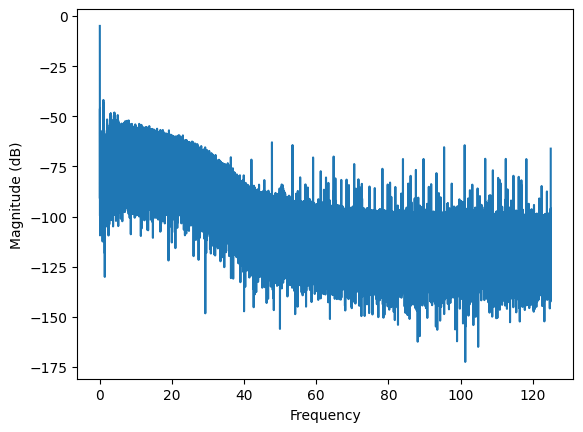

In [ ]:
x = signal[:,0]
plt.magnitude_spectrum(x, Fs=fs, scale='dB')

**Operación de pre-procesamiento. Quitamos el componente DC (offset)**

(array([4.74946500e-04, 1.27628085e-03, 7.93420901e-04, ...,
        7.44656934e-06, 2.47440103e-04, 4.95887162e-04]),
 array([0.00000000e+00, 1.38888889e-04, 2.77777778e-04, ...,
        1.24999722e+02, 1.24999861e+02, 1.25000000e+02]),
 <matplotlib.lines.Line2D at 0x7bcb1f9973b0>)

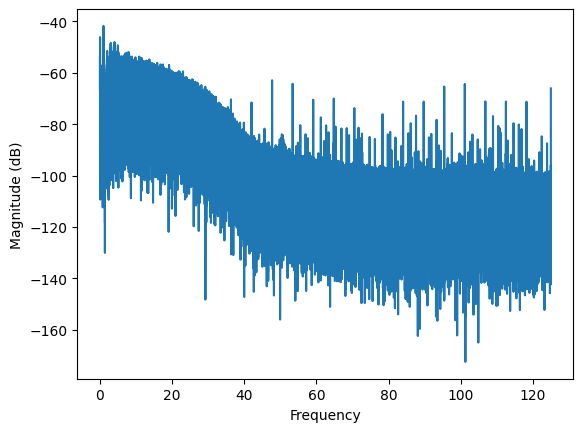

In [ ]:
x_dc_removed = x - np.mean(x)

plt.magnitude_spectrum(x_dc_removed, Fs=fs, scale='dB')

**Transformada Rápida de Fourier (FFT)**

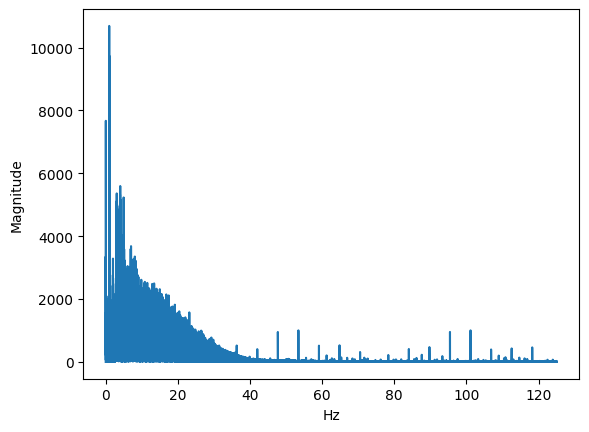

In [ ]:
X = np.fft.fft(x_dc_removed)
freqs = np.fft.fftfreq(len(x_dc_removed), 1/fs)

plt.plot(freqs[:len(x_dc_removed)//2], np.abs(X[:len(x_dc_removed)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.show()

**Aplicamos filtro pasa banda de orden 4**

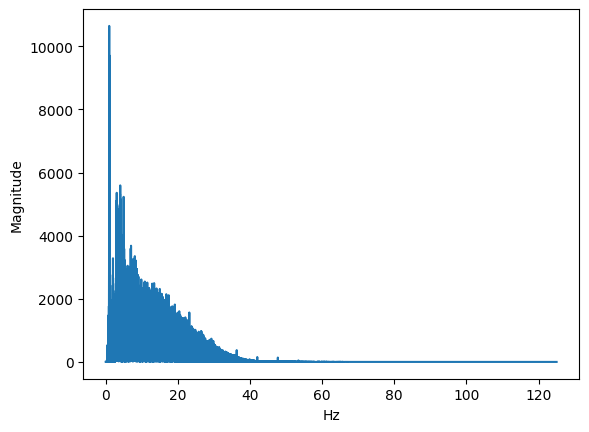

In [ ]:
from scipy.signal import butter, filtfilt

def bandpass(signal, fs, low=0.5, high=40):
    b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, signal)

filtered = bandpass(signal[:,0], fs)

X = np.fft.fft(filtered)
freqs = np.fft.fftfreq(len(filtered), 1/fs)

plt.plot(freqs[:len(filtered)//2], np.abs(X[:len(filtered)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.show()

**Comparacion de señales**

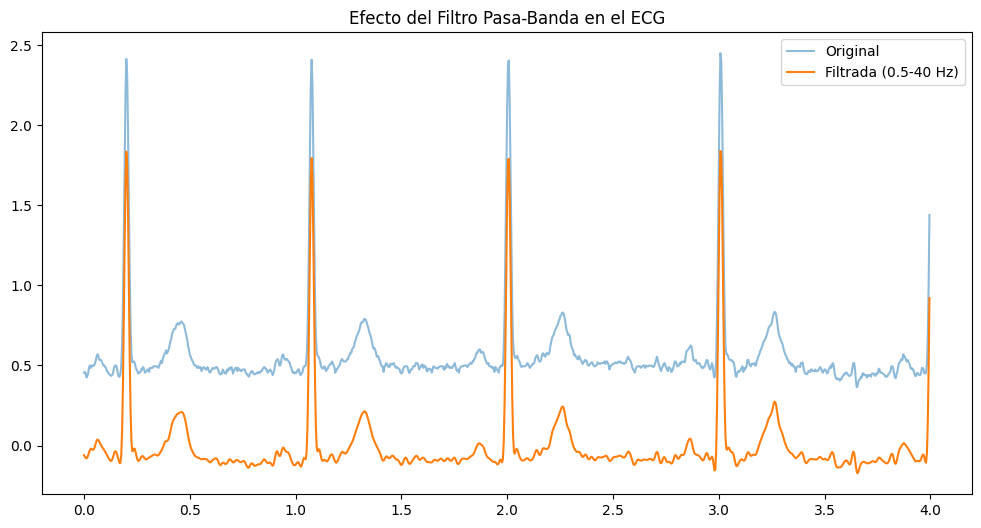

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(t[:1000], signal[:1000, 0], label='Original', alpha=0.5)
plt.plot(t[:1000], filtered[:1000], label='Filtrada (0.5-40 Hz)', linewidth=1.5)
plt.legend()
plt.title("Efecto del Filtro Pasa-Banda en el ECG")
plt.show()

**Segmentación por Ventanas y Extracciòn de caracteristicas**

Text(0.5, 1.0, 'Señal filtrada - 2 segundos')

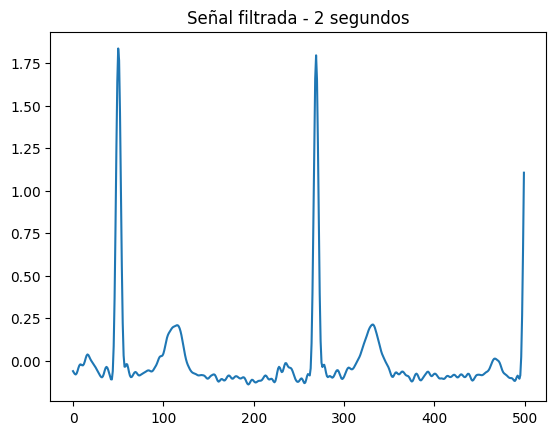

In [ ]:
window_size = int(2 * fs)  # 2 segundos
segments = []

for i in range(0, len(filtered)-window_size, window_size):
    segments.append(filtered[i:i+window_size])

#Extraemos las caracteristicas
def extract_features(segment):
    return [
        np.mean(segment),
        np.std(segment),
        np.max(segment)
    ]
#Visualizamos el primer bloque de 2 segundos de la señal ya filtrada
plt.plot(segments[0])
plt.title("Señal filtrada - 2 segundos")